Training Accuracy (Random Forest): 0.994
Training Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.99      1.00      0.99       185
           2       1.00      0.99      0.99       143

    accuracy                           0.99       328
   macro avg       0.99      0.99      0.99       328
weighted avg       0.99      0.99      0.99       328

Training Confusion Matrix (Random Forest):
[[185   0]
 [  2 141]]


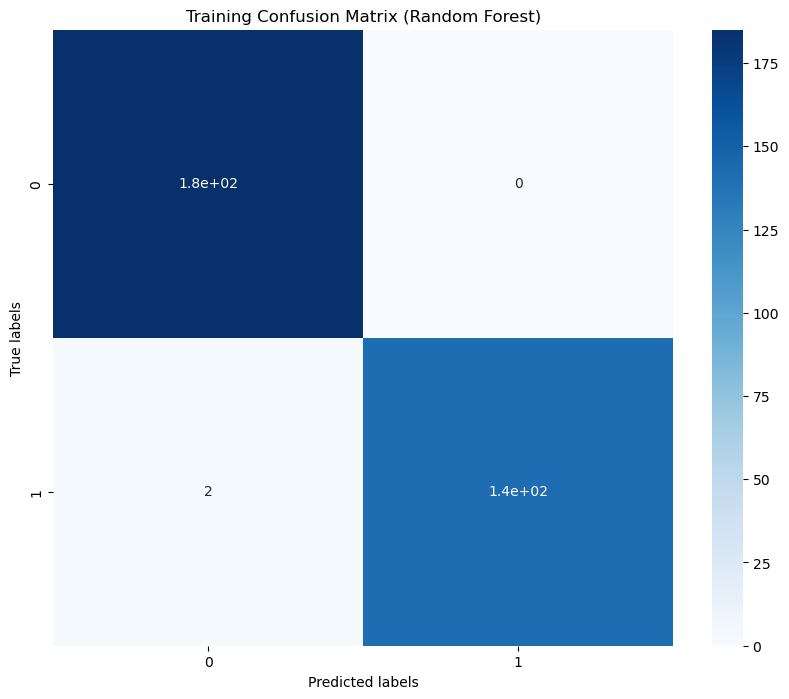

Test Accuracy (Random Forest): 0.783
Test Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.88      0.78      0.82        54
           2       0.66      0.79      0.72        29

    accuracy                           0.78        83
   macro avg       0.77      0.79      0.77        83
weighted avg       0.80      0.78      0.79        83

Test Confusion Matrix (Random Forest):
[[42 12]
 [ 6 23]]


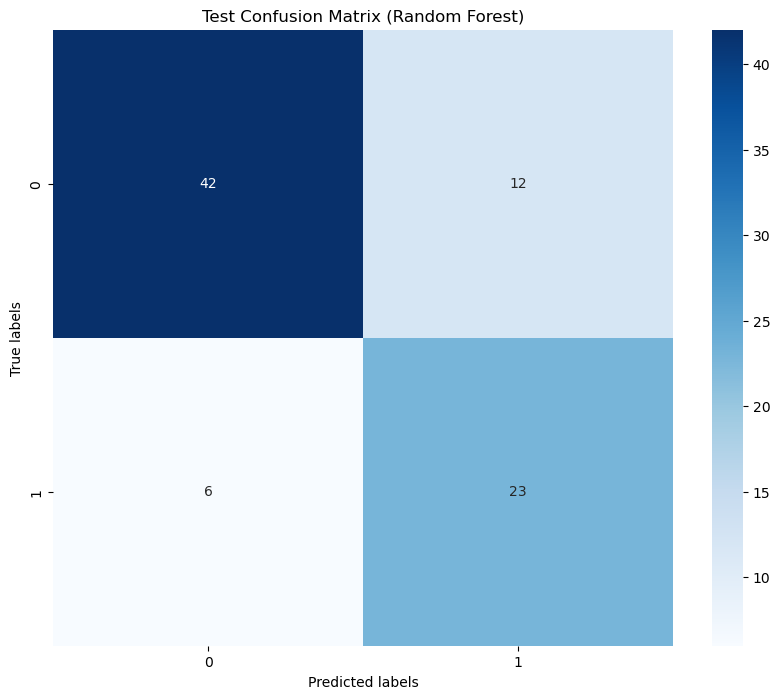

Training Accuracy (Gradient Boosting): 0.994
Training Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           1       1.00      0.99      0.99       185
           2       0.99      1.00      0.99       143

    accuracy                           0.99       328
   macro avg       0.99      0.99      0.99       328
weighted avg       0.99      0.99      0.99       328

Training Confusion Matrix (Gradient Boosting):
[[183   2]
 [  0 143]]


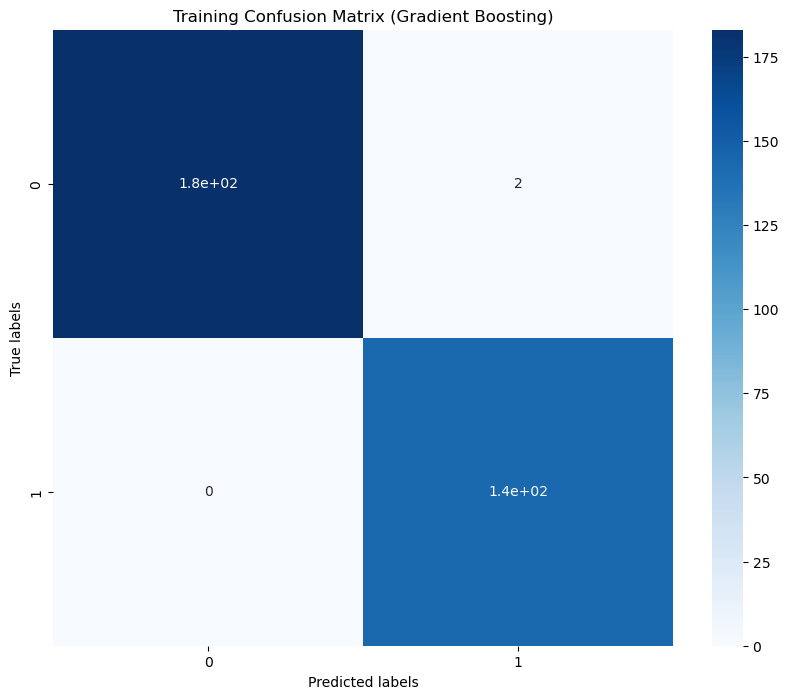

Test Accuracy (Gradient Boosting): 0.843
Test Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           1       0.94      0.81      0.87        54
           2       0.72      0.90      0.80        29

    accuracy                           0.84        83
   macro avg       0.83      0.86      0.84        83
weighted avg       0.86      0.84      0.85        83

Test Confusion Matrix (Gradient Boosting):
[[44 10]
 [ 3 26]]


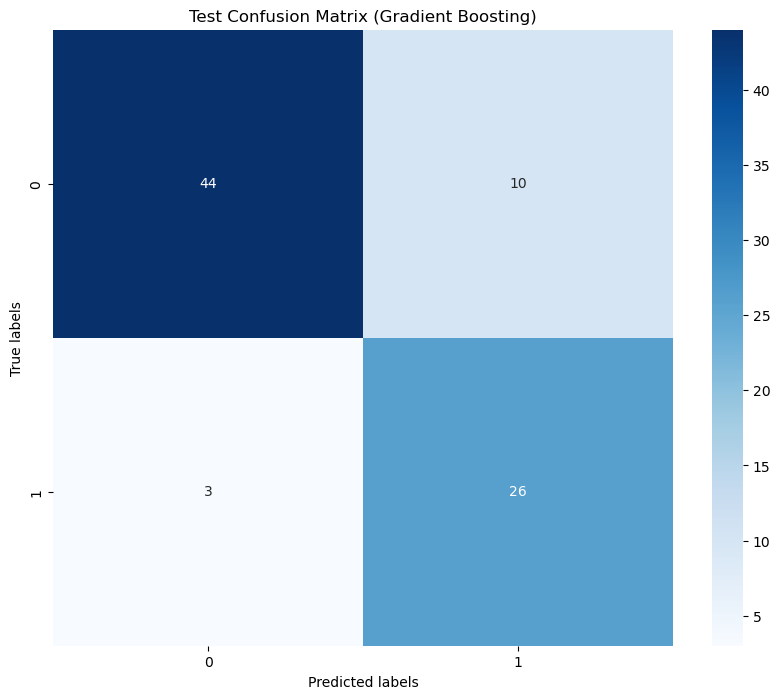

Training Accuracy (SVM): 0.820
Training Classification Report (SVM):
              precision    recall  f1-score   support

           1       0.85      0.83      0.84       185
           2       0.79      0.80      0.80       143

    accuracy                           0.82       328
   macro avg       0.82      0.82      0.82       328
weighted avg       0.82      0.82      0.82       328

Training Confusion Matrix (SVM):
[[154  31]
 [ 28 115]]


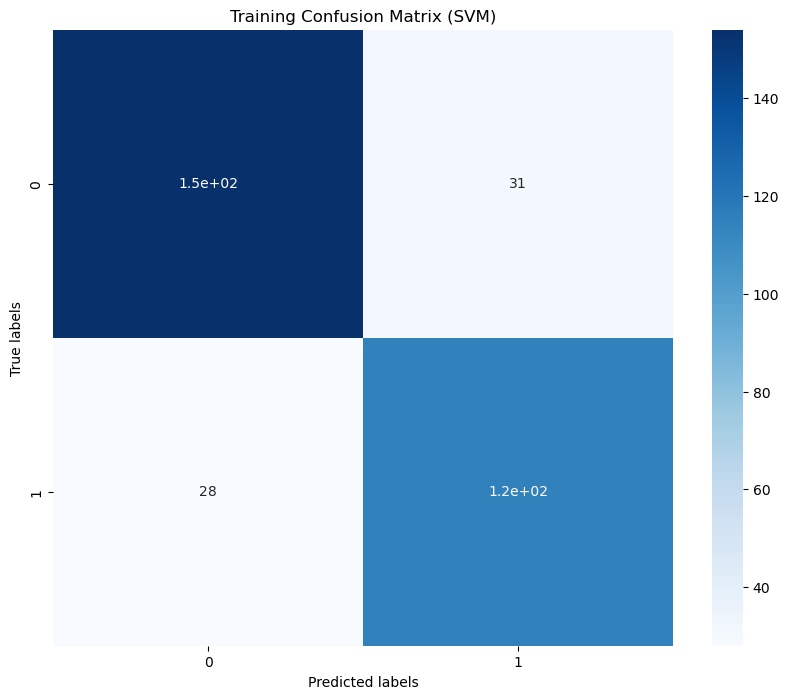

Test Accuracy (SVM): 0.711
Test Classification Report (SVM):
              precision    recall  f1-score   support

           1       0.84      0.69      0.76        54
           2       0.56      0.76      0.65        29

    accuracy                           0.71        83
   macro avg       0.70      0.72      0.70        83
weighted avg       0.74      0.71      0.72        83

Test Confusion Matrix (SVM):
[[37 17]
 [ 7 22]]


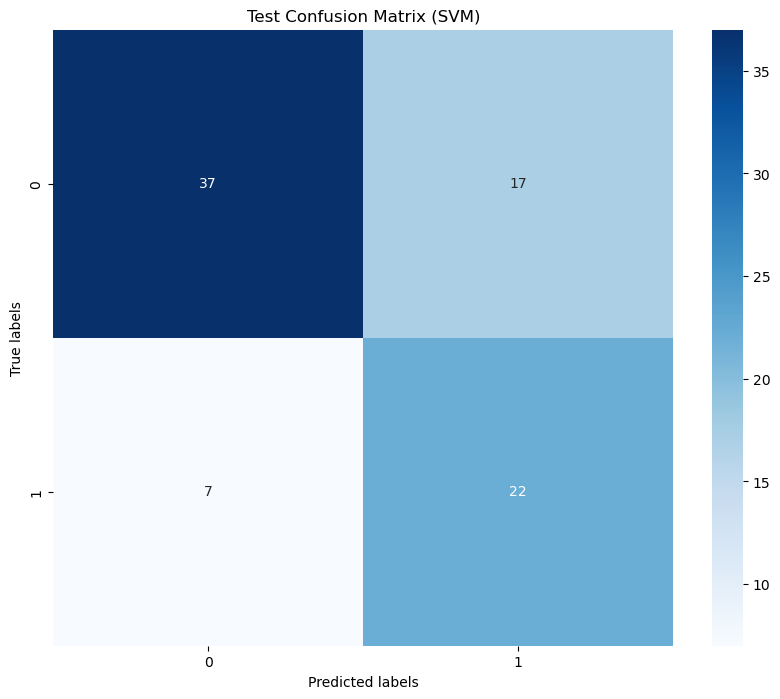

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV data
df1 = pd.read_csv('cleaned_x_data_XRDa_featuresNoise.csv')
df2 = pd.read_csv('y_data_kind.csv')

# Split the data into X (features) and y (target)
X = df1 # features (all columns except 'formula' and 'kind')
y = df2['kind']  # target variable (kind 1 to 6)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a RandomForestClassifier model
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred = rfc.predict(X_train_scaled)
y_test_pred = rfc.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train = accuracy_score(y_train, y_train_pred)
print(f'Training Accuracy (Random Forest): {accuracy_train:.3f}')

print('Training Classification Report (Random Forest):')
print(classification_report(y_train, y_train_pred))

print('Training Confusion Matrix (Random Forest):')
print(confusion_matrix(y_train, y_train_pred))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (Random Forest)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f'Test Accuracy (Random Forest): {accuracy_test:.3f}')

print('Test Classification Report (Random Forest):')
print(classification_report(y_test, y_test_pred))

print('Test Confusion Matrix (Random Forest):')
print(confusion_matrix(y_test, y_test_pred))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (Random Forest)')
plt.show()

# Train a GradientBoostingClassifier model
gbc = GradientBoostingClassifier(n_estimators=200, random_state=42)
gbc.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred_gbc = gbc.predict(X_train_scaled)
y_test_pred_gbc = gbc.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train_gbc = accuracy_score(y_train, y_train_pred_gbc)
print(f'Training Accuracy (Gradient Boosting): {accuracy_train_gbc:.3f}')

print('Training Classification Report (Gradient Boosting):')
print(classification_report(y_train, y_train_pred_gbc))

print('Training Confusion Matrix (Gradient Boosting):')
print(confusion_matrix(y_train, y_train_pred_gbc))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred_gbc), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (Gradient Boosting)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test_gbc = accuracy_score(y_test, y_test_pred_gbc)
print(f'Test Accuracy (Gradient Boosting): {accuracy_test_gbc:.3f}')

print('Test Classification Report (Gradient Boosting):')
print(classification_report(y_test, y_test_pred_gbc))

print('Test Confusion Matrix (Gradient Boosting):')
print(confusion_matrix(y_test, y_test_pred_gbc))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_gbc), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (Gradient Boosting)')
plt.show()

# Train a Support Vector Machines model
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred_svm = svm.predict(X_train_scaled)
y_test_pred_svm = svm.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train_svm = accuracy_score(y_train, y_train_pred_svm)
print(f'Training Accuracy (SVM): {accuracy_train_svm:.3f}')

print('Training Classification Report (SVM):')
print(classification_report(y_train, y_train_pred_svm))

print('Training Confusion Matrix (SVM):')
print(confusion_matrix(y_train, y_train_pred_svm))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred_svm), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (SVM)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test_svm = accuracy_score(y_test, y_test_pred_svm)
print(f'Test Accuracy (SVM): {accuracy_test_svm:.3f}')

print('Test Classification Report (SVM):')
print(classification_report(y_test, y_test_pred_svm))

print('Test Confusion Matrix (SVM):')
print(confusion_matrix(y_test, y_test_pred_svm))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_svm), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (SVM)')
plt.show()